Accuracy : 0.7587
Precision: 0.3284
Recall   : 0.5183
F1-score : 0.4020


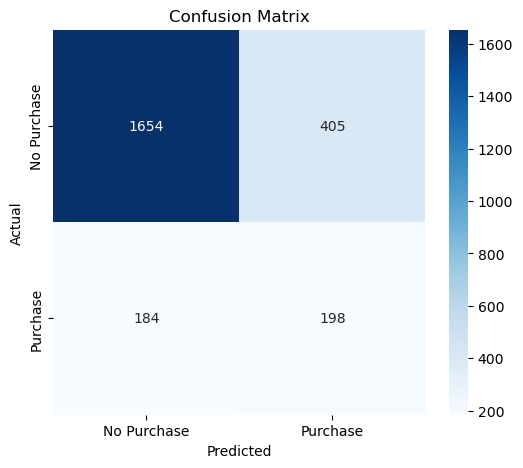

C:\Users\user\AppData\Local\Temp\ipykernel_5460\1652187079.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices][:10], y=X_train.columns[indices][:10], palette='viridis')


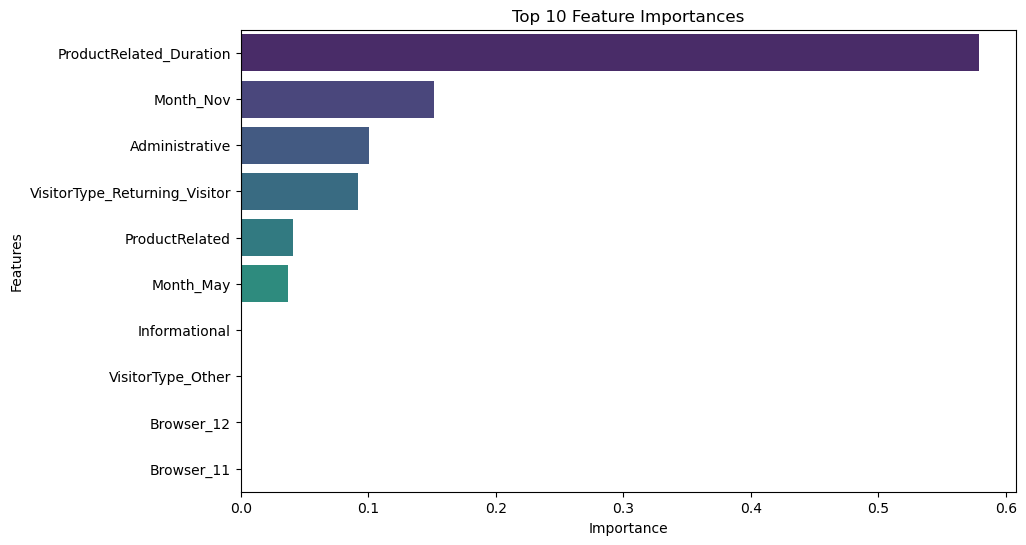


--- Decision Tree Rules ---
|--- ProductRelated_Duration <= 324.50
|   |--- Administrative <= 0.50
|   |   |--- ProductRelated_Duration <= 95.50
|   |   |   |--- class: 0
|   |   |--- ProductRelated_Duration >  95.50
|   |   |   |--- class: 0
|   |--- Administrative >  0.50
|   |   |--- Month_May <= 0.50
|   |   |   |--- class: 0
|   |   |--- Month_May >  0.50
|   |   |   |--- class: 0
|--- ProductRelated_Duration >  324.50
|   |--- Month_Nov <= 0.50
|   |   |--- VisitorType_Returning_Visitor <= 0.50
|   |   |   |--- class: 1
|   |   |--- VisitorType_Returning_Visitor >  0.50
|   |   |   |--- class: 0
|   |--- Month_Nov >  0.50
|   |   |--- ProductRelated <= 76.50
|   |   |   |--- class: 1
|   |   |--- ProductRelated >  76.50
|   |   |   |--- class: 1



In [1]:
import sys
import subprocess

# 필수 라이브러리 체크 및 자동 설치
modules = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'sklearn']
for mod in modules:
    try:
        __import__(mod)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", mod if mod != 'sklearn' else 'scikit-learn'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 데이터 로드 및 PageValues 제거
X_train = pd.read_csv('csv/X_train.csv').drop(columns=['PageValues'])
X_test = pd.read_csv('csv/X_test.csv').drop(columns=['PageValues'])
y_train = pd.read_csv('csv/y_train.csv').values.ravel()
y_test = pd.read_csv('csv/y_test.csv').values.ravel()

# 모델 정의 및 학습
model = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# 예측 및 평가지표 출력
y_pred = model.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")

# Confusion Matrix 시각화 및 저장
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Purchase', 'Purchase'], 
            yticklabels=['No Purchase', 'Purchase'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix_final.png', bbox_inches='tight')
plt.show()

# Feature Importance 시각화 및 저장
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices][:10], y=X_train.columns[indices][:10], palette='viridis')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.savefig('feature_importance_final.png', bbox_inches='tight')
plt.show()

# 트리 분기 규칙 출력
print("\n--- Decision Tree Rules ---")
print(export_text(model, feature_names=list(X_train.columns)))

Accuracy : 0.7587
Precision: 0.3284
Recall   : 0.5183
F1-score : 0.4020


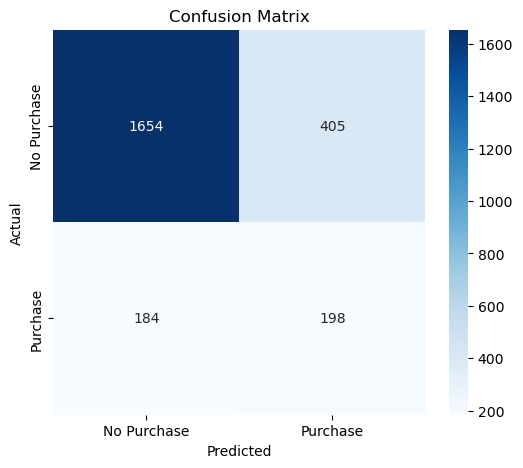

C:\Users\user\AppData\Local\Temp\ipykernel_12864\2632524871.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices][:10], y=X_train.columns[indices][:10], palette='viridis')


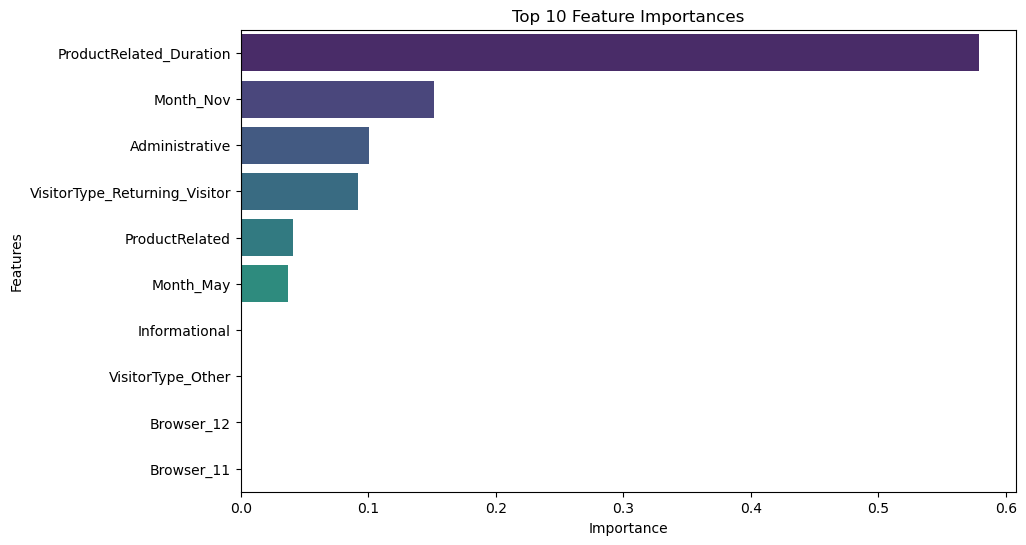


--- Decision Tree Rules ---
|--- ProductRelated_Duration <= 324.50
|   |--- Administrative <= 0.50
|   |   |--- ProductRelated_Duration <= 95.50
|   |   |   |--- class: 0
|   |   |--- ProductRelated_Duration >  95.50
|   |   |   |--- class: 0
|   |--- Administrative >  0.50
|   |   |--- Month_May <= 0.50
|   |   |   |--- class: 0
|   |   |--- Month_May >  0.50
|   |   |   |--- class: 0
|--- ProductRelated_Duration >  324.50
|   |--- Month_Nov <= 0.50
|   |   |--- VisitorType_Returning_Visitor <= 0.50
|   |   |   |--- class: 1
|   |   |--- VisitorType_Returning_Visitor >  0.50
|   |   |   |--- class: 0
|   |--- Month_Nov >  0.50
|   |   |--- ProductRelated <= 76.50
|   |   |   |--- class: 1
|   |   |--- ProductRelated >  76.50
|   |   |   |--- class: 1



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 데이터 로드 및 PageValues 제거
X_train = pd.read_csv('csv/X_train.csv').drop(columns=['PageValues'])
X_test = pd.read_csv('csv/X_test.csv').drop(columns=['PageValues'])
y_train = pd.read_csv('csv/y_train.csv').values.ravel()
y_test = pd.read_csv('csv/y_test.csv').values.ravel()

# 수업 모델 기반 설정: criterion='gini' 명시
model = DecisionTreeClassifier(criterion='gini', max_depth=3, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# 예측 및 평가지표 출력
y_pred = model.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")

# Confusion Matrix 시각화 및 저장
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Purchase', 'Purchase'], 
            yticklabels=['No Purchase', 'Purchase'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix_final.png', bbox_inches='tight')
plt.show()

# Feature Importance 시각화 및 저장
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices][:10], y=X_train.columns[indices][:10], palette='viridis')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.savefig('feature_importance_final.png', bbox_inches='tight')
plt.show()

# 트리 분기 규칙 출력
print("\n--- Decision Tree Rules ---")
print(export_text(model, feature_names=list(X_train.columns)))